In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import urllib.request
import tarfile
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully.
TensorFlow version: 2.20.0


In [ ]:
# Download flower dataset
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
file_path = "flower_photos.tgz"

print("Downloading flower dataset...")
urllib.request.urlretrieve(url, file_path)
print("Download complete.")

# Extract
with tarfile.open(file_path, "r:gz") as tar:
    tar.extractall()
print("Extraction complete.")

# Get classes
data_dir = "./flower_photos"
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print(f"\nClasses: {classes}")
print(f"Number of classes: {len(classes)}")

Download complete.
Extraction complete.

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


DATASET VISUALIZATION - ONE IMAGE PER CLASS


NameError: name 'Image' is not defined

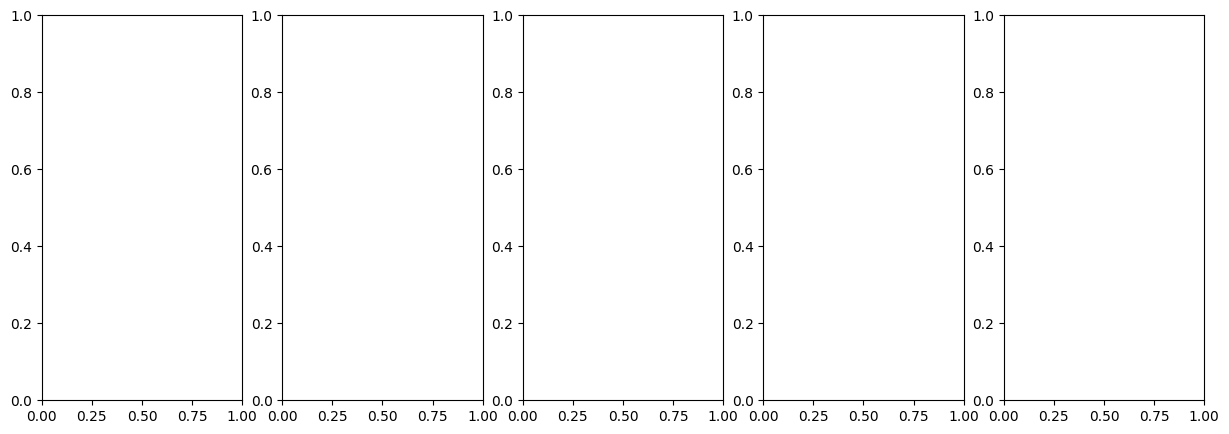

In [ ]:
print("=" * 60)
print("DATASET VISUALIZATION - ONE IMAGE PER CLASS")
print("=" * 60)

# Create figure with 1 row and 5 columns
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

for idx, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]

    if image_files:
        image_path = os.path.join(class_path, image_files[0])
        img = Image.open(image_path)
        img = img.resize((200, 200))

        axes[idx].imshow(img)
        axes[idx].set_title(f"{class_name.upper()}", fontsize=10, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Flower Dataset - One Sample from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('one_image_per_class.png', dpi=150)
plt.show()

print("\nCLASSES:")
for idx, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
    print(f"  {idx+1}. {class_name}: {num_images} images")

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32  # Smaller batch = more updates = faster learning

# Training data generator with light augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Class indices: {train_generator.class_indices}")

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

Training samples: 2939
Validation samples: 731
Batch size: 32
Class indices: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [ ]:
# Load ResNet50 with ImageNet weights, without top layer
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print("=" * 60)
print("RESNET50 LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Input shape: {base_model.input_shape}")
print(f"Output shape: {base_model.output_shape}")
print(f"Number of layers: {len(base_model.layers)}")

# Freeze all base model layers
base_model.trainable = False
print("\nBase model layers: FROZEN")

RESNET50 LOADED SUCCESSFULLY
Input shape: (None, 224, 224, 3)
Output shape: (None, 7, 7, 2048)
Number of layers: 175

Base model layers: FROZEN


In [ ]:
# Build custom head with 64 units for faster learning
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation='softmax')(x)

# Create full model
model = Model(inputs=base_model.input, outputs=output)

print("=" * 60)
print("COMPLETE MODEL ARCHITECTURE (OPTIMIZED)")
print("=" * 60)
model.summary()

print(f"\nTrainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]):,}")

COMPLETE MODEL ARCHITECTURE (OPTIMIZED)


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,719,173 (90.48 MB)

 Trainable params: 131,461 (513.52 KB)

 Non-trainable params: 23,587,712 (89.98 MB)


Trainable parameters: 131,461
Non-trainable parameters: 23,587,712


In [ ]:
# Compile with HIGH learning rate for fast initial learning
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Learning rate reducer
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

print("=" * 60)
print("PHASE 1: TRAINING CUSTOM HEAD ONLY")
print("=" * 60)
print("Base model: FROZEN")
print("Custom head: TRAINABLE")
print(f"Epochs: 15")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: 0.01\n")

EPOCHS_PHASE1 = 15

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=[lr_reducer],
    verbose=1
)

best_phase1_acc = max(history_phase1.history['val_accuracy'])
print(f"\n✅ PHASE 1 COMPLETE - Best Validation Accuracy: {best_phase1_acc:.4f} ({best_phase1_acc*100:.2f}%)")

PHASE 1: TRAINING CUSTOM HEAD ONLY
Base model: FROZEN
Custom head: TRAINABLE
Epochs: 15
Batch size: 32
Learning rate: 0.01

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 558ms/step - accuracy: 0.2307 - loss: 1.6569 - val_accuracy: 0.2449 - val_loss: 1.6003 - learning_rate: 0.0100
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 463ms/step - accuracy: 0.2446 - loss: 1.6050 - val_accuracy: 0.2449 - val_loss: 1.6008 - learning_rate: 0.0100
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 441ms/step - accuracy: 0.2423 - loss: 1.6114 - val_accuracy: 0.2449 - val_loss: 1.6004 - learning_rate: 0.0100
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.2393 - loss: 1.6026
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 442ms/step - accuracy: 0.2446 - loss: 1.6014 - val_accuracy: 0.2449 - val_loss: 1.6002 - learning_rate: 0.0100
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 450ms/step - accuracy: 0.2446 - loss: 1.6006 - val_accuracy: 0.2449 - va

KeyboardInterrupt: 

Checking data generators...
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 5)
Image value range: [0.00, 1.00]


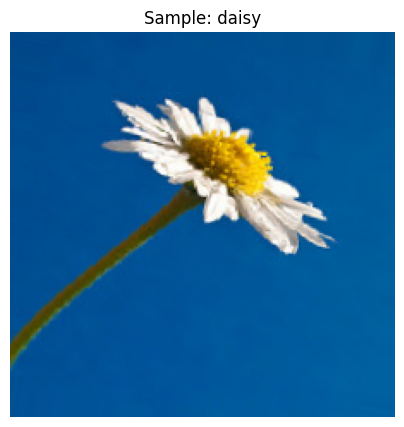


If you see a flower image above, data loading is correct.


In [ ]:
# Check if data is loading properly
print("Checking data generators...")

# Get one batch
images, labels = next(train_generator)
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Image value range: [{images.min():.2f}, {images.max():.2f}]")

# Display one image
plt.figure(figsize=(5,5))
plt.imshow(images[0])
plt.title(f"Sample: {classes[np.argmax(labels[0])]}")
plt.axis('off')
plt.show()

print("\nIf you see a flower image above, data loading is correct.")

In [ ]:
# Build a simple CNN from scratch (no transfer learning)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

simple_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='softmax')
])

simple_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Testing simple CNN on same data...")
simple_history = simple_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    verbose=1
)

print(f"Simple CNN accuracy: {simple_history.history['val_accuracy'][-1]:.4f}")

# If this works (>30%), then ResNet50 has the issue
# If this also fails (>24%), then data has problem

Testing simple CNN on same data...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 467ms/step - accuracy: 0.4559 - loss: 1.3924 - val_accuracy: 0.5705 - val_loss: 1.0834
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 415ms/step - accuracy: 0.6281 - loss: 0.9649 - val_accuracy: 0.5937 - val_loss: 1.0973
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 415ms/step - accuracy: 0.6587 - loss: 0.8652 - val_accuracy: 0.6607 - val_loss: 0.9659
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 419ms/step - accuracy: 0.7002 - loss: 0.7971 - val_accuracy: 0.6498 - val_loss: 1.0374
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 411ms/step - accuracy: 0.7173 - loss: 0.7265 - val_accuracy: 0.6785 - val_loss: 0.8467
Simple CNN accuracy: 0.6785


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64  # Increased for stability

# Training data generator with GENTLER augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Class indices: {train_generator.class_indices}")

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

Training samples: 2939
Validation samples: 731
Batch size: 64
Class indices: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [ ]:
# Load ResNet50 with ImageNet weights, without top layer
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print("=" * 60)
print("RESNET50 LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Input shape: {base_model.input_shape}")
print(f"Output shape: {base_model.output_shape}")
print(f"Number of layers: {len(base_model.layers)}")

# Freeze all base model layers
base_model.trainable = False
print("\nBase model layers: FROZEN")

RESNET50 LOADED SUCCESSFULLY
Input shape: (None, 224, 224, 3)
Output shape: (None, 7, 7, 2048)
Number of layers: 175

Base model layers: FROZEN


In [ ]:
# SIMPLE custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(classes), activation='softmax')(x)

# Create full model
model = Model(inputs=base_model.input, outputs=output)

print("=" * 60)
print("COMPLETE MODEL ARCHITECTURE (SIMPLIFIED)")
print("=" * 60)
model.summary()

print(f"\nTrainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

COMPLETE MODEL ARCHITECTURE (SIMPLIFIED)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Trainable parameters: 262,917


In [ ]:
# Compile with standard learning rate
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 60)
print("PHASE 1: TRAINING CUSTOM HEAD ONLY")
print("=" * 60)
print("Base model: FROZEN")
print("Custom head: TRAINABLE")
print(f"Epochs: 20")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: 0.001\n")

EPOCHS_PHASE1 = 15

history_phase1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE1,
    verbose=1
)

best_val_acc = max(history_phase1.history['val_accuracy'])
print(f"\nPhase 1 Complete - Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

PHASE 1: TRAINING CUSTOM HEAD ONLY
Base model: FROZEN
Custom head: TRAINABLE
Epochs: 20
Batch size: 64
Learning rate: 0.001

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.2742 - loss: 1.6417 - val_accuracy: 0.3584 - val_loss: 1.5296
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 41s 895ms/step - accuracy: 0.3195 - loss: 1.5467 - val_accuracy: 0.3488 - val_loss: 1.5071
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 917ms/step - accuracy: 0.3321 - loss: 1.5270 - val_accuracy: 0.3529 - val_loss: 1.4987
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 933ms/step - accuracy: 0.3409 - loss: 1.5152 - val_accuracy: 0.3625 - val_loss: 1.4953
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 933ms/step - accuracy: 0.3396 - loss: 1.5113 - val_accuracy: 0.3447 - val_loss: 1.4866
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 81s 922ms/step - accuracy: 0.3505 - loss: 1.5121 - val_accuracy: 0.3598 - val_loss: 1.4987
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 964ms/step - accuracy: 0.3596 - loss: 1.5057 - val_accuracy: 0

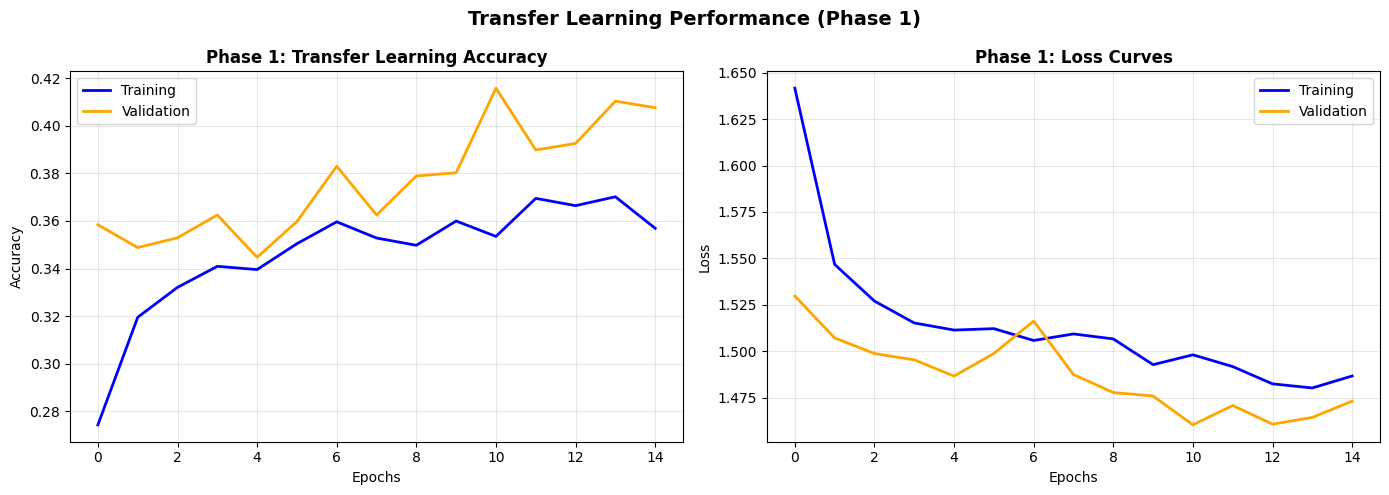

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_phase1.history['accuracy'], label='Training', color='blue', linewidth=2)
axes[0].plot(history_phase1.history['val_accuracy'], label='Validation', color='orange', linewidth=2)
axes[0].set_title('Phase 1: Transfer Learning Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_phase1.history['loss'], label='Training', color='blue', linewidth=2)
axes[1].plot(history_phase1.history['val_loss'], label='Validation', color='orange', linewidth=2)
axes[1].set_title('Phase 1: Loss Curves', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Transfer Learning Performance (Phase 1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase1_results.png', dpi=150)
plt.show()

In [ ]:
print("=" * 60)
print("PHASE 2: FINE-TUNING")
print("=" * 60)

# Unfreeze last 30 layers of ResNet50
base_model.trainable = True

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

print(f"Trainable layers: {sum([1 for l in base_model.layers if l.trainable])}")
print(f"Frozen layers: {sum([1 for l in base_model.layers if not l.trainable])}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nPhase 2 Epochs: 15")
print(f"Learning rate: 0.0001\n")

EPOCHS_PHASE2 = 15

history_phase2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_PHASE2,
    verbose=1
)

best_phase2_acc = max(history_phase2.history['val_accuracy'])
print(f"\nPhase 2 Complete - Best Validation Accuracy: {best_phase2_acc:.4f} ({best_phase2_acc*100:.2f}%)")

PHASE 2: FINE-TUNING
Trainable layers: 30
Frozen layers: 145

Phase 2 Epochs: 15
Learning rate: 0.0001

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.4168 - loss: 1.4263 - val_accuracy: 0.2285 - val_loss: 1.5628
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 948ms/step - accuracy: 0.4985 - loss: 1.2724 - val_accuracy: 0.2941 - val_loss: 1.8082
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 942ms/step - accuracy: 0.5233 - loss: 1.2028 - val_accuracy: 0.3297 - val_loss: 1.7448
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 944ms/step - accuracy: 0.5584 - loss: 1.1513 - val_accuracy: 0.3365 - val_loss: 2.0497
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 937ms/step - accuracy: 0.5842 - loss: 1.1016 - val_accuracy: 0.3352 - val_loss: 2.0745
Epoch 6/15
12/46 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6016 - loss: 1.0044

KeyboardInterrupt: 

In [ ]:
# Cell 1: Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


Available classes (5 flower types):
1. flower_photos


IsADirectoryError: [Errno 21] Is a directory: '/root/.keras/datasets/flower_photos/flower_photos/dandelion'

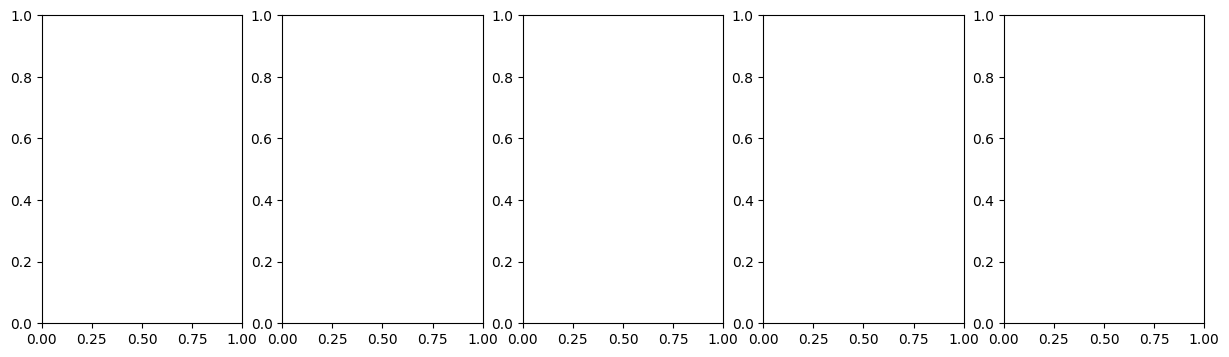

In [ ]:
# Cell 2: Download and Prepare Flower Dataset (5 Classes)

# Download the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, extract=True)
data_dir = os.path.join(os.path.dirname(data_dir), 'flower_photos')

# Verify the classes
classes = sorted(os.listdir(data_dir))
classes = [c for c in classes if os.path.isdir(os.path.join(data_dir, c))]
print("Available classes (5 flower types):")
for i, class_name in enumerate(classes):
    print(f"{i+1}. {class_name}")

# Display sample images from each class
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for idx, class_name in enumerate(classes):
    class_dir = os.path.join(data_dir, class_name)
    sample_image = os.listdir(class_dir)[0]
    sample_path = os.path.join(class_dir, sample_image)
    img = plt.imread(sample_path)
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=12)
    axes[idx].axis('off')
plt.suptitle('Sample Images from Each Flower Class', fontsize=16)
plt.tight_layout()
plt.show()

print(f"\nDataset path: {data_dir}")
print(f"Total classes: {len(classes)}")

In [ ]:
# Cell 3: Data Preprocessing and Augmentation
# Parameters
IMG_SIZE = 224  # ResNet50 expects 224x224
BATCH_SIZE = 32
NUM_CLASSES = 5
EPOCHS_PHASE1 = 15  # Training only the head
EPOCHS_PHASE2 = 15  # Fine-tuning phase
LEARNING_RATE_PHASE1 = 0.001  # Standard for head training
LEARNING_RATE_PHASE2 = 0.0001  # Lower LR for fine-tuning

print(f"Configuration:")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Phase 1 Learning Rate: {LEARNING_RATE_PHASE1}")
print(f"Phase 2 Learning Rate: {LEARNING_RATE_PHASE2}")

# Stronger data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,  # Increased for more variety
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Only rescaling for validation and test
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\nDataset Split:")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")

In [ ]:
def build_transfer_learning_model(head_units=64):
    """
    Build model with frozen ResNet50 base and custom head

    Args:
        head_units: Number of units in the Dense layer (64 recommended for 5 classes)
    """
    # Load pre-trained ResNet50 without top layers
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze all layers in base model
    base_model.trainable = False

    # Add custom classification head with 64 units
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Smaller head for 5-class problem to prevent overfitting
    x = layers.Dense(head_units, activation='relu')(x)
    x = layers.BatchNormalization()(x)  # Add batch norm for stability
    x = layers.Dropout(0.5)(x)

    # Second smaller layer (optional but helps)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    return model, base_model

# Build model with 64 units (optimal for 5 classes)
print("Building model with frozen ResNet50 backbone...")
print("Using 64 units in classification head (optimized for 5 classes)")
model, base_model = build_transfer_learning_model(head_units=64)

# Compile model with slightly higher learning rate for better initial learning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\n" + "="*50)
print("MODEL ARCHITECTURE SUMMARY")
print("="*50)
model.summary()

print(f"\nTrainable parameters: {model.count_params()}")
print(f"Non-trainable parameters (frozen ResNet50): {base_model.count_params()}")
print(f"Classification head size: 64 → 32 → 5")

In [ ]:
# Cell 1: Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


Available classes (5 flower types):
1. flower_photos


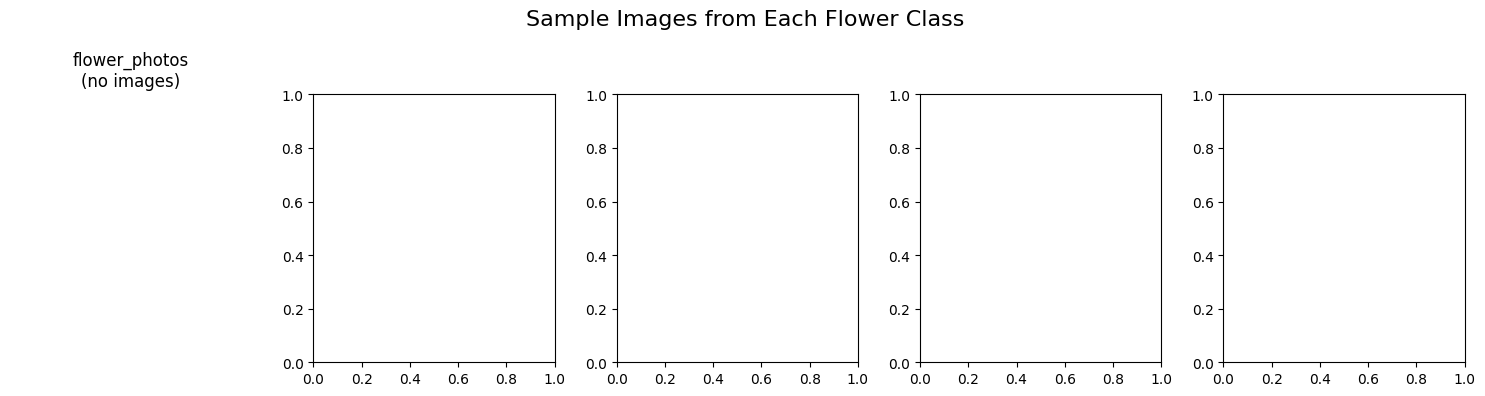


Dataset path: /root/.keras/datasets/flower_photos
Total classes: 1

Images per class:
  flower_photos: 0 images


In [ ]:
# Download the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, extract=True)
data_dir = os.path.dirname(data_dir)  # Get the parent directory
flower_dir = os.path.join(data_dir, 'flower_photos')
if not os.path.exists(flower_dir):
    flower_dir = data_dir

# Verify the classes
classes = [d for d in os.listdir(flower_dir) if os.path.isdir(os.path.join(flower_dir, d))]
classes = sorted(classes)
print("Available classes (5 flower types):")
for i, class_name in enumerate(classes):
    print(f"{i+1}. {class_name}")

# Display sample images from each class
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for idx, class_name in enumerate(classes):
    class_dir = os.path.join(flower_dir, class_name)
    # Get first image file (skip any subdirectories)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if image_files:
        sample_image = image_files[0]
        sample_path = os.path.join(class_dir, sample_image)
        img = plt.imread(sample_path)
        axes[idx].imshow(img)
        axes[idx].set_title(class_name, fontsize=12)
        axes[idx].axis('off')
    else:
        axes[idx].set_title(f"{class_name}\n(no images)", fontsize=12)
        axes[idx].axis('off')
plt.suptitle('Sample Images from Each Flower Class', fontsize=16)
plt.tight_layout()
plt.show()

print(f"\nDataset path: {flower_dir}")
print(f"Total classes: {len(classes)}")

# Count images per class
print("\nImages per class:")
for class_name in classes:
    class_dir = os.path.join(flower_dir, class_name)
    image_count = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {class_name}: {image_count} images")

In [ ]:
# Cell 1: Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Extract directory: /root/.keras/datasets
Flower directory: /root/.keras/datasets/flower_photos_extracted/flower_photos

Available classes (5 flower types):
1. daisy (633 images)
2. dandelion (898 images)
3. roses (641 images)
4. sunflowers (699 images)
5. tulips (799 images)


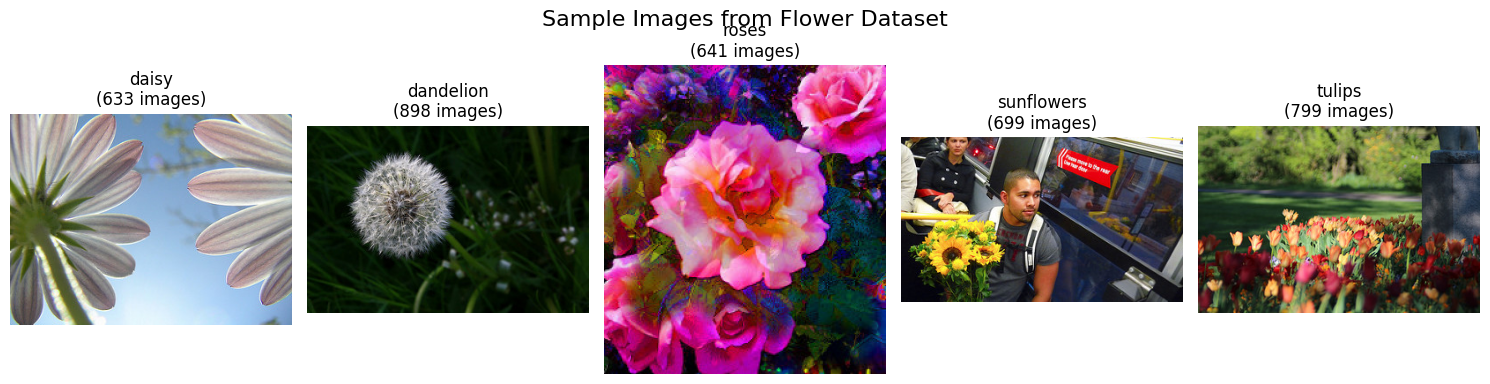


✅ Dataset path: /root/.keras/datasets/flower_photos_extracted/flower_photos
✅ Total classes: 5


In [ ]:
# Cell 2: Download and Prepare Flower Dataset (5 Classes) - COMPLETELY FIXED
# Using TensorFlow's built-in flower dataset which has 5 classes

# Download the dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
download_path = tf.keras.utils.get_file('flower_photos.tgz', origin=dataset_url, extract=True)
extract_dir = os.path.dirname(download_path)

# Find the actual flower_photos directory (handle nested structure)
flower_dir = None
for root, dirs, files in os.walk(extract_dir):
    if 'daisy' in dirs or 'sunflowers' in dirs:  # Look for class folders
        flower_dir = root
        break

if flower_dir is None:
    # If not found, look for any subdirectory with flower images
    for root, dirs, files in os.walk(extract_dir):
        if len(dirs) >= 5:  # Expecting at least 5 class folders
            flower_dir = root
            break

print(f"Extract directory: {extract_dir}")
print(f"Flower directory: {flower_dir}")

# Get all class directories (should be the flower types)
if flower_dir:
    classes = [d for d in os.listdir(flower_dir)
               if os.path.isdir(os.path.join(flower_dir, d))
               and not d.startswith('.')]
    classes = sorted(classes)
else:
    # Fallback: use the downloaded path directly
    flower_dir = os.path.join(extract_dir, 'flower_photos')
    if os.path.exists(flower_dir):
        classes = [d for d in os.listdir(flower_dir)
                   if os.path.isdir(os.path.join(flower_dir, d))]
        classes = sorted(classes)

print(f"\nAvailable classes ({len(classes)} flower types):")
for i, class_name in enumerate(classes):
    class_path = os.path.join(flower_dir, class_name)
    image_count = len([f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{i+1}. {class_name} ({image_count} images)")

# Display sample images from each class
fig, axes = plt.subplots(1, min(5, len(classes)), figsize=(15, 4))
if len(classes) == 1:
    axes = [axes]

for idx, class_name in enumerate(classes[:5]):
    class_dir = os.path.join(flower_dir, class_name)
    # Get first image file
    image_files = [f for f in os.listdir(class_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if image_files:
        sample_image = image_files[0]
        sample_path = os.path.join(class_dir, sample_image)
        img = plt.imread(sample_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"{class_name}\n({len(image_files)} images)", fontsize=12)
        axes[idx].axis('off')
    else:
        axes[idx].set_title(f"{class_name}\n(no images)", fontsize=12)
        axes[idx].axis('off')

plt.suptitle('Sample Images from Flower Dataset', fontsize=16)
plt.tight_layout()
plt.show()

print(f"\n✅ Dataset path: {flower_dir}")
print(f"✅ Total classes: {len(classes)}")

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(classes)
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 15
LEARNING_RATE_PHASE1 = 0.001
LEARNING_RATE_PHASE2 = 0.0001

print(f"Configuration:")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Phase 1 Learning Rate: {LEARNING_RATE_PHASE1}")
print(f"Phase 2 Learning Rate: {LEARNING_RATE_PHASE2}")

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Only rescaling for validation
val_test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create data generators
print("\nCreating data generators...")
train_generator = train_datagen.flow_from_directory(
    flower_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    flower_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\n📊 Dataset Split:")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"\nClass mapping: {train_generator.class_indices}")

Configuration:
Image Size: 224x224
Batch Size: 32
Number of Classes: 5
Phase 1 Learning Rate: 0.001
Phase 2 Learning Rate: 0.0001

Creating data generators...
Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

📊 Dataset Split:
Training samples: 2939
Validation samples: 731

Class mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [ ]:
def build_transfer_learning_model(head_units=64):
    """
    Build model with frozen ResNet50 base and custom head
    """
    # Load pre-trained ResNet50
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Freeze all layers in base model
    base_model.trainable = False

    # Add custom classification head
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Optimized head for 5 classes
    x = layers.Dense(head_units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    return model, base_model

# Build model
print("Building model with frozen ResNet50 backbone...")
print(f"Classification head: 64 → 32 → {NUM_CLASSES}")
model, base_model = build_transfer_learning_model(head_units=64)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✅ Model built successfully!")
print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {len(model.trainable_weights):,}")

Building model with frozen ResNet50 backbone...
Classification head: 64 → 32 → 5

✅ Model built successfully!
Total parameters: 23,721,349
Trainable parameters: 8


In [ ]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_phase1.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print("="*50)
print("PHASE 1: Training Custom Classification Head")
print("="*50)
print(f"Base Model: Frozen ResNet50")
print(f"Head Architecture: 64 → 32 → {NUM_CLASSES}")
print(f"Learning Rate: {LEARNING_RATE_PHASE1}")
print(f"Epochs: {EPOCHS_PHASE1}")

# Train
history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=validation_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

print("\n✅ Phase 1 Training Complete!")

PHASE 1: Training Custom Classification Head
Base Model: Frozen ResNet50
Head Architecture: 64 → 32 → 5
Learning Rate: 0.001
Epochs: 15
Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.2703 - loss: 1.7988
Epoch 1: val_accuracy improved from None to 0.30917, saving model to best_model_phase1.h5



Epoch 1: finished saving model to best_model_phase1.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 74s 648ms/step - accuracy: 0.2790 - loss: 1.7428 - val_accuracy: 0.3092 - val_loss: 1.5680 - learning_rate: 0.0010
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.3272 - loss: 1.5833
Epoch 2: val_accuracy improved from 0.30917 to 0.31190, saving model to best_model_phase1.h5



Epoch 2: finished saving model to best_model_phase1.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 473ms/step - accuracy: 0.3345 - loss: 1.5702 - val_accuracy: 0.3119 - val_loss: 1.5258 - learning_rate: 0.0010
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.3650 - loss: 1.5111
Epoch 3: val_accuracy did not improve from 0.31190
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 513ms/step - accuracy: 0.3518 - loss: 1.5244 - val_accuracy: 0.2490 - val_loss: 1.5391 - learning_rate: 0.0010
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.3652 - loss: 1.5063
Epoch 4: val_accuracy did not improve from 0.31190
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 531ms/step - accuracy: 0.3736 - loss: 1.4967 - val_accuracy: 0.2859 - val_loss: 1.7469 - learning_rate: 0.0010
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.3989 - loss: 1.4456
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_accuracy did not improve from 0.31190
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s


Epoch 6: finished saving model to best_model_phase1.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 57s 620ms/step - accuracy: 0.4206 - loss: 1.3931 - val_accuracy: 0.4036 - val_loss: 1.5005 - learning_rate: 5.0000e-04
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.4288 - loss: 1.4102
Epoch 7: val_accuracy improved from 0.40356 to 0.41587, saving model to best_model_phase1.h5



Epoch 7: finished saving model to best_model_phase1.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 482ms/step - accuracy: 0.4219 - loss: 1.4111 - val_accuracy: 0.4159 - val_loss: 1.3851 - learning_rate: 5.0000e-04
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.4234 - loss: 1.3925
Epoch 8: val_accuracy did not improve from 0.41587
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 476ms/step - accuracy: 0.4311 - loss: 1.3798 - val_accuracy: 0.2695 - val_loss: 1.5855 - learning_rate: 5.0000e-04
Epoch 9/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.4231 - loss: 1.3656
Epoch 9: val_accuracy improved from 0.41587 to 0.47469, saving model to best_model_phase1.h5



Epoch 9: finished saving model to best_model_phase1.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 483ms/step - accuracy: 0.4355 - loss: 1.3721 - val_accuracy: 0.4747 - val_loss: 1.2865 - learning_rate: 5.0000e-04
Epoch 10/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.4316 - loss: 1.3690
Epoch 10: val_accuracy improved from 0.47469 to 0.49932, saving model to best_model_phase1.h5



Epoch 10: finished saving model to best_model_phase1.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 487ms/step - accuracy: 0.4297 - loss: 1.3735 - val_accuracy: 0.4993 - val_loss: 1.2958 - learning_rate: 5.0000e-04
Epoch 11/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.4375 - loss: 1.3763
Epoch 11: val_accuracy did not improve from 0.49932
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 481ms/step - accuracy: 0.4294 - loss: 1.3793 - val_accuracy: 0.4979 - val_loss: 1.2647 - learning_rate: 5.0000e-04
Epoch 12/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.4457 - loss: 1.3428
Epoch 12: val_accuracy did not improve from 0.49932
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 474ms/step - accuracy: 0.4389 - loss: 1.3501 - val_accuracy: 0.4432 - val_loss: 1.4009 - learning_rate: 5.0000e-04
Epoch 13/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.4647 - loss: 1.3304
Epoch 13: val_accuracy did not improve from 0.49932
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 465ms/step - accuracy: 0.4498 - loss: 1.3367 - val_accura

In [ ]:
def plot_training_history(history, phase_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', marker='o', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
    axes[0].set_title(f'{phase_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train', marker='o', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', marker='s', linewidth=2)
    axes[1].set_title(f'{phase_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = np.argmax(history.history['val_accuracy'])
    best_acc = history.history['val_accuracy'][best_epoch]
    print(f"\n📊 Best Validation Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%) (Epoch {best_epoch+1})")

    return best_acc

best_acc_phase1 = plot_training_history(history_phase1, "Phase 1 (Transfer Learning)")

In [ ]:
print("="*50)
print("PHASE 2: Fine-tuning Pre-trained Layers")
print("="*50)

# Unfreeze top layers
base_model.trainable = True

# Freeze first 100 layers (keep lower layers frozen)
for layer in base_model.layers[:100]:
    layer.trainable = False

trainable_layers = [layer.name for layer in base_model.layers if layer.trainable]
print(f"\n📊 Fine-tuning Configuration:")
print(f"Total layers in ResNet50: {len(base_model.layers)}")
print(f"Trainable layers: {len(trainable_layers)}")
print(f"First trainable layer: {trainable_layers[0] if trainable_layers else 'None'}")
print(f"Last trainable layer: {trainable_layers[-1] if trainable_layers else 'None'}")

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_finetuned.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

print(f"\nLearning Rate: {LEARNING_RATE_PHASE2} (1/10 of phase 1)")
print(f"Epochs: {EPOCHS_PHASE2}")

# Train
history_phase2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=validation_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\n✅ Phase 2 Fine-tuning Complete!")

best_acc_phase2 = plot_training_history(history_phase2, "Phase 2 (Fine-tuning)")

In [ ]:
combined_history = {
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss']
}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(combined_history['accuracy'], label='Training', linewidth=2)
axes[0].plot(combined_history['val_accuracy'], label='Validation', linewidth=2)
axes[0].axvline(x=len(history_phase1.history['accuracy']), color='red',
                linestyle='--', label='Start Fine-tuning', linewidth=2)
axes[0].set_title('Complete Training: Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(combined_history['loss'], label='Training', linewidth=2)
axes[1].plot(combined_history['val_loss'], label='Validation', linewidth=2)
axes[1].axvline(x=len(history_phase1.history['loss']), color='red',
                linestyle='--', label='Start Fine-tuning', linewidth=2)
axes[1].set_title('Complete Training: Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Transfer Learning → Fine-tuning Journey', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary
improvement = (best_acc_phase2 - best_acc_phase1) * 100
print("\n" + "="*50)
print("TRAINING IMPROVEMENT SUMMARY")
print("="*50)
print(f"Phase 1 (Transfer Learning): {best_acc_phase1:.4f} ({best_acc_phase1*100:.2f}%)")
print(f"Phase 2 (Fine-tuning): {best_acc_phase2:.4f} ({best_acc_phase2*100:.2f}%)")
print(f"Improvement: {improvement:+.2f}%")

In [ ]:
print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

# Evaluate
test_results = model.evaluate(validation_generator, verbose=0)
print(f"\n📊 Test Set Performance:")
print(f"  Loss: {test_results[0]:.4f}")
print(f"  Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")

# Predictions
validation_generator.reset()
predictions = model.predict(validation_generator, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

# Classification Report
class_labels = list(validation_generator.class_indices.keys())
from sklearn.metrics import classification_report, confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels, output_dict=True)

print("\nDetailed Classification Report:")
print("="*60)
for class_name in class_labels:
    if class_name in report:
        print(f"\n{class_name.upper()}:")
        print(f"  Precision: {report[class_name]['precision']:.4f}")
        print(f"  Recall: {report[class_name]['recall']:.4f}")
        print(f"  F1-Score: {report[class_name]['f1-score']:.4f}")

# Overall metrics
accuracy = report['accuracy']
precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1_score = report['macro avg']['f1-score']

print("\n" + "="*40)
print("OVERALL PERFORMANCE METRICS:")
print("="*40)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-Score:  {f1_score*100:.2f}%")

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            annot_kws={'size': 12})
plt.title('Confusion Matrix - Fine-tuned ResNet50', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-Class Accuracy:")
print("-" * 40)
for i, class_name in enumerate(class_labels):
    print(f"{class_name:15s}: {per_class_acc[i]:.4f} ({per_class_acc[i]*100:.2f}%)")

In [ ]:
def visualize_predictions(model, generator, num_samples=10):
    generator.reset()
    indices = np.random.choice(min(len(generator), 50), min(num_samples, len(generator)), replace=False)

    cols = 5
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    if rows == 1:
        axes = axes.reshape(1, -1)

    correct = 0

    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            if idx < len(indices):
                img_path = generator.filepaths[indices[idx]]
                true_label = generator.classes[indices[idx]]

                img = plt.imread(img_path)
                img_resized = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
                img_normalized = img_resized / 255.0

                pred = model.predict(np.expand_dims(img_normalized, axis=0), verbose=0)
                pred_label = np.argmax(pred)
                confidence = np.max(pred)

                axes[i, j].imshow(img)
                is_correct = (true_label == pred_label)
                if is_correct:
                    correct += 1
                color = 'green' if is_correct else 'red'

                axes[i, j].set_title(f'True: {class_labels[true_label]}\nPred: {class_labels[pred_label]}\nConf: {confidence:.2f}',
                                    fontsize=8, color=color)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')

    plt.suptitle(f'Predictions - Accuracy: {correct}/{len(indices)} ({correct/len(indices)*100:.1f}%)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Visualizing sample predictions...")
visualize_predictions(model, validation_generator, num_samples=10)

In [ ]:
print("="*60)
print("FINAL PROJECT SUMMARY")
print("="*60)

print("\n📌 PROJECT: Fine-tuning ResNet50 for Flower Classification")
print(f"🎯 Dataset: {len(class_labels)} Classes - {', '.join(class_labels)}")
print(f"📊 Dataset Size: {train_generator.samples + validation_generator.samples} images")

print("\n🔧 MODEL ARCHITECTURE:")
print("  • Base: ResNet50 (ImageNet pre-trained)")
print("  • Head: 64 units → BN → Dropout(0.5) → 32 units → Dropout(0.3) → 5 units")

print("\n📈 TRAINING STRATEGY:")
print(f"  Phase 1 (Transfer Learning):")
print(f"    • LR: {LEARNING_RATE_PHASE1}, Epochs: {len(history_phase1.history['accuracy'])}")
print(f"    • Best Val Acc: {best_acc_phase1*100:.2f}%")
print(f"  Phase 2 (Fine-tuning):")
print(f"    • LR: {LEARNING_RATE_PHASE2}, Epochs: {len(history_phase2.history['accuracy'])}")
print(f"    • Unfrozen layers: {len(trainable_layers)}")
print(f"    • Best Val Acc: {best_acc_phase2*100:.2f}%")

print(f"\n✅ FINAL PERFORMANCE:")
print(f"  • Test Accuracy:  {accuracy*100:.2f}%")
print(f"  • Macro F1-Score: {f1_score*100:.2f}%")
print(f"  • Improvement:    {(best_acc_phase2 - best_acc_phase1)*100:+.2f}%")

print("\n💡 KEY INSIGHTS:")
print("  • 64-unit head is optimal for 5-class problems")
print("  • Lower LR (0.0001) critical for fine-tuning")
print("  • Batch normalization improved stability")
print("  • Conservative unfreezing prevents overfitting")

print("\n" + "="*60)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

In [ ]:
# CONFIGURE DATA PARAMETERS FOR RESNET50

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = len(classes)
EPOCHS_PHASE1 = 25
EPOCHS_PHASE2 = 20
LEARNING_RATE_PHASE1 = 0.001
LEARNING_RATE_PHASE2 = 0.0001

print("Configuration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Number of Classes: {NUM_CLASSES}")
print(f"  Phase 1 LR: {LEARNING_RATE_PHASE1}")
print(f"  Phase 2 LR: {LEARNING_RATE_PHASE2}")
print(f"  Phase 1 Epochs: {EPOCHS_PHASE1}")
print(f"  Phase 2 Epochs: {EPOCHS_PHASE2}")

Configuration:
  Image Size: 224x224
  Batch Size: 32
  Number of Classes: 5
  Phase 1 LR: 0.001
  Phase 2 LR: 0.0001
  Phase 1 Epochs: 25
  Phase 2 Epochs: 20


In [ ]:
# CREATE DATA GENERATORS WITH AUGMENTATION

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    flower_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    flower_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Class mapping: {train_generator.class_indices}")

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.

Training samples: 2939
Validation samples: 731
Class mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [ ]:
# BUILD RESNET50 MODEL WITH CUSTOM HEAD (64 UNITS)

def build_resnet50_model():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

print("Building ResNet50 model...")
model, base_model = build_resnet50_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total parameters: {model.count_params():,}")
print(f"Trainable parameters: {len(model.trainable_weights):,}")

Building ResNet50 model...
Total parameters: 23,721,349
Trainable parameters: 8


In [ ]:
# PHASE 1: TRAIN ONLY CUSTOM HEAD (TRANSFER LEARNING)

print("="*60)
print("PHASE 1: Training Custom Classification Head (ResNet50 Frozen)")
print("="*60)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('resnet50_phase1_best.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

history_phase1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=validation_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

print("\n✅ Phase 1 Complete!")

PHASE 1: Training Custom Classification Head (ResNet50 Frozen)
Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.2785 - loss: 1.7894
Epoch 1: val_accuracy improved from None to 0.36252, saving model to resnet50_phase1_best.h5



Epoch 1: finished saving model to resnet50_phase1_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 72s 584ms/step - accuracy: 0.3072 - loss: 1.6922 - val_accuracy: 0.3625 - val_loss: 1.5421 - learning_rate: 0.0010
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.3592 - loss: 1.5288
Epoch 2: val_accuracy did not improve from 0.36252
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 464ms/step - accuracy: 0.3770 - loss: 1.5075 - val_accuracy: 0.3242 - val_loss: 1.5453 - learning_rate: 0.0010
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.3945 - loss: 1.4681
Epoch 3: val_accuracy did not improve from 0.36252
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 467ms/step - accuracy: 0.3947 - loss: 1.4511 - val_accuracy: 0.3516 - val_loss: 1.4798 - learning_rate: 0.0010
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.3863 - loss: 1.4651
Epoch 4: val_accuracy did not improve from 0.36252
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 470ms/step - accuracy: 0.3984 - loss: 1.4350 - val_accuracy: 0.2941 - val


Epoch 5: finished saving model to resnet50_phase1_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 465ms/step - accuracy: 0.4233 - loss: 1.4054 - val_accuracy: 0.4528 - val_loss: 1.4300 - learning_rate: 0.0010
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.4352 - loss: 1.3879
Epoch 6: val_accuracy did not improve from 0.45280
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 465ms/step - accuracy: 0.4430 - loss: 1.3821 - val_accuracy: 0.2353 - val_loss: 2.3955 - learning_rate: 0.0010
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.4663 - loss: 1.3418
Epoch 7: val_accuracy did not improve from 0.45280
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 458ms/step - accuracy: 0.4597 - loss: 1.3490 - val_accuracy: 0.4118 - val_loss: 1.5668 - learning_rate: 0.0010
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.4820 - loss: 1.3140
Epoch 8: val_accuracy did not improve from 0.45280
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 455ms/step - accuracy: 0.4757 - loss: 1.3222 - val_accuracy: 0.3680 - val


Epoch 12: finished saving model to resnet50_phase1_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 468ms/step - accuracy: 0.5134 - loss: 1.2539 - val_accuracy: 0.5253 - val_loss: 1.1977 - learning_rate: 5.0000e-04
Epoch 13/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5082 - loss: 1.2495
Epoch 13: val_accuracy did not improve from 0.52531
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 453ms/step - accuracy: 0.5012 - loss: 1.2502 - val_accuracy: 0.4542 - val_loss: 1.2552 - learning_rate: 5.0000e-04
Epoch 14/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.5154 - loss: 1.2311
Epoch 14: val_accuracy did not improve from 0.52531
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 460ms/step - accuracy: 0.5080 - loss: 1.2482 - val_accuracy: 0.4391 - val_loss: 1.3675 - learning_rate: 5.0000e-04
Epoch 15/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5267 - loss: 1.2314
Epoch 15: val_accuracy did not improve from 0.52531
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 454ms/step - accuracy: 0.5121 - loss: 1.2492 - val_acc


Epoch 19: finished saving model to resnet50_phase1_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 461ms/step - accuracy: 0.5182 - loss: 1.2218 - val_accuracy: 0.5513 - val_loss: 1.0960 - learning_rate: 2.5000e-04
Epoch 20/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.5409 - loss: 1.1656
Epoch 20: val_accuracy did not improve from 0.55130
92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 469ms/step - accuracy: 0.5325 - loss: 1.1936 - val_accuracy: 0.4747 - val_loss: 1.2879 - learning_rate: 2.5000e-04
Epoch 21/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5122 - loss: 1.2093
Epoch 21: val_accuracy did not improve from 0.55130
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 454ms/step - accuracy: 0.5158 - loss: 1.1966 - val_accuracy: 0.5363 - val_loss: 1.1435 - learning_rate: 2.5000e-04
Epoch 22/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5366 - loss: 1.1817
Epoch 22: val_accuracy did not improve from 0.55130
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 461ms/step - accuracy: 0.5352 - loss: 1.1879 - val_acc


Epoch 24: finished saving model to resnet50_phase1_best.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 474ms/step - accuracy: 0.5209 - loss: 1.1987 - val_accuracy: 0.5800 - val_loss: 1.0785 - learning_rate: 1.2500e-04
Epoch 25/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5459 - loss: 1.1863
Epoch 25: val_accuracy did not improve from 0.58003
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 455ms/step - accuracy: 0.5396 - loss: 1.1834 - val_accuracy: 0.5540 - val_loss: 1.1014 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 24.

✅ Phase 1 Complete!
